# 🏗️ Pipeline de Preprocesamiento
## Casas Usadas — Región Metropolitana, Mayo 2020
**Asignatura:** SCY1101 — Programación para la Ciencia de Datos

---

### Objetivo
Construir, ejecutar y validar el pipeline completo de scikit-learn que transforma
el dataset crudo en datos listos para modelado de Machine Learning.


## 0. Configuración

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Calcular la ruta absoluta a la raíz del proyecto desde la ubicación del notebook
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))

# Agregar raíz al path para poder importar src/
sys.path.insert(0, PROJECT_ROOT)

# Cambiar el directorio de trabajo a la raíz del proyecto
os.chdir(PROJECT_ROOT)

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print(f"Entorno configurado")
print(f"Raíz del proyecto: {PROJECT_ROOT}")

Entorno configurado
Raíz del proyecto: c:\Users\AB\Downloads\casas_rm_project (6)\casas_rm_project


## 1. Auditoría de Integridad

In [2]:
from src.audit import audit_data

resultado_auditoria = audit_data()
print(f"\nResultado de auditoría: {'APROBADA' if resultado_auditoria else 'FALLIDA'}")

🔍 Auditando archivo: Casas_usadas_-_RM_Mayo_2020.xlsx
✅ ÉXITO: Integridad verificada. El archivo no ha sido alterado.
   SHA-256: cf754539191d41ff745c3c46f774e2e2...

Resultado de auditoría: APROBADA


## 2. Carga y Optimización de Memoria

In [3]:
from src.optimization import optimize_memory, load_excel_in_chunks

# Cargar en chunks (demostración de procesamiento a gran escala)
df_raw = load_excel_in_chunks('data/raw/Casas_usadas_-_RM_Mayo_2020.xlsx', chunk_size=300)
print(f"\nDimensiones raw: {df_raw.shape}")

📦 Cargando 1139 filas en chunks de 300...
   Chunk 1: filas 0–300 ✓
   Chunk 2: filas 300–600 ✓
   Chunk 3: filas 600–900 ✓
   Chunk 4: filas 900–1139 ✓
✅ Dataset ensamblado: 1139 filas × 13 columnas

Dimensiones raw: (1139, 13)


In [4]:
# Optimización de memoria
df_opt = optimize_memory(df_raw)
print(f"\nDimensiones optimizadas: {df_opt.shape}")

💾 Memoria original: 0.68 MB
🚀 Memoria optimizada: 0.35 MB
📉 Ahorro total: 49.0%

Dimensiones optimizadas: (1139, 13)


## 3. Demostración de Transformadores Individuales

### 3.1 DropColumnsTransformer

In [5]:
from src.transformers import DropColumnsTransformer

COLS_ELIMINAR = ['Link', 'Tipo_Vivienda', 'Dirección', 'Quién_Vende', 'Corredor']
dropper = DropColumnsTransformer(columns_to_drop=COLS_ELIMINAR)
df_step1 = dropper.fit_transform(df_opt)
print(f"Columnas antes: {df_opt.shape[1]} → después: {df_step1.shape[1]}")
print(f"Columnas restantes: {list(df_step1.columns)}")

   🗑️  DropColumns: eliminadas ['Link', 'Tipo_Vivienda', 'Dirección', 'Quién_Vende', 'Corredor']
Columnas antes: 13 → después: 8
Columnas restantes: ['Comuna', 'N_Habitaciones', 'N_Baños', 'N_Estacionamientos', 'Total_Superficie_M2', 'Superficie_Construida_M2', 'Valor_UF', 'Valor_CLP']


### 3.2 ParkingToNumericTransformer

In [6]:
from src.transformers import ParkingToNumericTransformer

print("Antes:", df_step1['N_Estacionamientos'].value_counts().head(5).to_dict())
parking_t = ParkingToNumericTransformer()
df_step2 = parking_t.fit_transform(df_step1)
print("Después (tipo):", df_step2['N_Estacionamientos'].dtype)
print("Estadísticas:", df_step2['N_Estacionamientos'].describe().to_dict())

Antes: {'No': 600, 2: 172, 1: 125, 3: 78, 4: 47}
   🔢 ParkingToNumeric: 'N_Estacionamientos' convertida a numérico.
Después (tipo): float64
Estadísticas: {'count': 1067.0, 'mean': 1.1134020618556701, 'std': 1.67457489509511, 'min': 0.0, '25%': 0.0, '50%': 0.0, '75%': 2.0, 'max': 10.0}


### 3.3 TargetCreatorTransformer

In [7]:
from src.transformers import TargetCreatorTransformer, SurfaceToNumericTransformer

surf_t = SurfaceToNumericTransformer()
df_step3 = surf_t.fit_transform(df_step2)

target_t = TargetCreatorTransformer()
df_step4 = target_t.fit_transform(df_step3)

print("Variable objetivo creada:")
print(df_step4['precio_sobre_mediana'].value_counts())
print(f"\n¿'Valor_UF' eliminada? {'No' if 'Valor_UF' in df_step4.columns else 'Sí'}")
print(f"¿'Valor_CLP' eliminada? {'No' if 'Valor_CLP' in df_step4.columns else 'Sí'}")

   🔢 SurfaceToNumeric: 'Superficie_Construida_M2' convertida a numérico.
   🎯 TargetCreator: mediana UF aprendida = 6700.00 UF
   🎯 TargetCreator: 568 casas SOBRE mediana | 571 casas BAJO mediana
   🚫 Leakage eliminado: ['Valor_UF', 'Valor_CLP']
Variable objetivo creada:
precio_sobre_mediana
0    571
1    568
Name: count, dtype: int64

¿'Valor_UF' eliminada? Sí
¿'Valor_CLP' eliminada? Sí


### 3.4 OutlierCapper (Winsorización)

In [8]:
from src.transformers import OutlierCapper

# Separar target antes del capper
target_col = df_step4['precio_sobre_mediana'].copy()
df_features = df_step4.drop(columns=['precio_sobre_mediana'])

capper = OutlierCapper(apply_capping=True)
df_step5 = capper.fit_transform(df_features)
df_step5['precio_sobre_mediana'] = target_col.values

print("Estadísticas N_Habitaciones ANTES:")
print(df_features['N_Habitaciones'].describe())
print("\nEstadísticas N_Habitaciones DESPUÉS:")
print(df_step5['N_Habitaciones'].describe())

   ✂️  OutlierCapper: 'N_Habitaciones' → 27 valores recortados [0.0, 8.0]
   ✂️  OutlierCapper: 'N_Baños' → 117 valores recortados [0.5, 4.5]
   ✂️  OutlierCapper: 'N_Estacionamientos' → 103 valores recortados [-3.0, 5.0]
   ✂️  OutlierCapper: 'Total_Superficie_M2' → 197 valores recortados [-395.6, 1139.4]
   ✂️  OutlierCapper: 'Superficie_Construida_M2' → 120 valores recortados [-86.8, 411.2]
Estadísticas N_Habitaciones ANTES:
count    1131.000000
mean        4.109637
std         1.602654
min         1.000000
25%         3.000000
50%         4.000000
75%         5.000000
max        19.000000
Name: N_Habitaciones, dtype: float64

Estadísticas N_Habitaciones DESPUÉS:
count    1131.000000
mean        4.056587
std         1.360108
min         1.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         8.000000
Name: N_Habitaciones, dtype: float64


### 3.5 SmartImputerTransformer

In [9]:
from src.transformers import SmartImputerTransformer, DropHighMissingTransformer

drop_nan = DropHighMissingTransformer(threshold=0.8)
df_step6 = drop_nan.fit_transform(df_step5)

print("Nulos ANTES de imputar:")
print(df_step6.isnull().sum()[df_step6.isnull().sum() > 0])

imputer = SmartImputerTransformer(low_threshold=0.10)
df_step7 = imputer.fit_transform(df_step6)

print("\nNulos DESPUÉS de imputar:")
nulos_post = df_step7.isnull().sum()
print(nulos_post[nulos_post > 0] if nulos_post.sum() > 0 else "✅ Sin nulos restantes")

Nulos ANTES de imputar:
N_Habitaciones               8
N_Baños                     21
N_Estacionamientos          72
Total_Superficie_M2         37
Superficie_Construida_M2    37
dtype: int64
   🧠 SmartImputer - Simples (<10%): ['N_Habitaciones', 'N_Baños', 'N_Estacionamientos', 'Total_Superficie_M2', 'Superficie_Construida_M2']
   🚧 SmartImputer - Complejas (10-80%): []
   💉 Imputados 8 nulos en 'N_Habitaciones' con 4.00
   💉 Imputados 21 nulos en 'N_Baños' con 2.00
   💉 Imputados 72 nulos en 'N_Estacionamientos' con 0.00
   💉 Imputados 37 nulos en 'Total_Superficie_M2' con 293.00
   💉 Imputados 37 nulos en 'Superficie_Construida_M2' con 140.00

Nulos DESPUÉS de imputar:
✅ Sin nulos restantes


## 4. Pipeline Completo de Scikit-Learn

In [10]:
from src.pipeline import build_preprocessing_pipeline

pipeline = build_preprocessing_pipeline()

print("Estructura del Pipeline:")
print("=" * 50)
for i, (name, step) in enumerate(pipeline.steps):
    print(f"  {i+1}. {name:<20} → {type(step).__name__}")

Estructura del Pipeline:
  1. drop_leaks           → DropColumnsTransformer
  2. parking_fix          → ParkingToNumericTransformer
  3. surface_fix          → SurfaceToNumericTransformer
  4. target_creator       → TargetCreatorTransformer
  5. drop_high_nan        → DropHighMissingTransformer
  6. outlier_capper       → OutlierCapper
  7. smart_imputer        → SmartImputerTransformer
  8. preprocessing        → ColumnTransformer


### Diagrama visual del Pipeline

In [ ]:
# Visualización interactiva del Pipeline
from sklearn import set_config
set_config(display='diagram')
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('drop_leaks', ...), ('parking_fix', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,columns_to_drop,"['Link', 'Tipo_Vivienda', ...]"
,col,'N_Estacionamientos'
,col,'Superficie_Construida_M2'
,uf_col,'Valor_UF'
,clp_col,'Valor_CLP'
,threshold,0.8
,apply_capping,True


In [12]:
# Ejecutar pipeline completo
print("Ejecutando pipeline sobre dataset original...\n")
X_processed = pipeline.fit_transform(df_opt)

print(f"\n✅ Dimensiones finales del dataset procesado:")
print(f"   {X_processed.shape[0]} filas × {X_processed.shape[1]} columnas")

Ejecutando pipeline sobre dataset original...

   🗑️  DropColumns: eliminadas ['Link', 'Tipo_Vivienda', 'Dirección', 'Quién_Vende', 'Corredor']
   🔢 ParkingToNumeric: 'N_Estacionamientos' convertida a numérico.
   🔢 SurfaceToNumeric: 'Superficie_Construida_M2' convertida a numérico.
   🎯 TargetCreator: mediana UF aprendida = 6700.00 UF
   🎯 TargetCreator: 568 casas SOBRE mediana | 571 casas BAJO mediana
   🚫 Leakage eliminado: ['Valor_UF', 'Valor_CLP']
   ✂️  OutlierCapper: 'N_Habitaciones' → 27 valores recortados [0.0, 8.0]
   ✂️  OutlierCapper: 'N_Baños' → 117 valores recortados [0.5, 4.5]
   ✂️  OutlierCapper: 'N_Estacionamientos' → 103 valores recortados [-3.0, 5.0]
   ✂️  OutlierCapper: 'Total_Superficie_M2' → 197 valores recortados [-395.6, 1139.4]
   ✂️  OutlierCapper: 'Superficie_Construida_M2' → 120 valores recortados [-86.8, 411.2]
   🧠 SmartImputer - Simples (<10%): ['N_Habitaciones', 'N_Baños', 'N_Estacionamientos', 'Total_Superficie_M2', 'Superficie_Construida_M2']
   🚧 Sm

## 5. Validación Post-Pipeline

In [13]:
# Reconstruir DataFrame con nombres de columnas
try:
    feature_names = pipeline.named_steps['preprocessing'].get_feature_names_out()
    feature_names = [n.replace('num__','').replace('cat__','') for n in feature_names]
except:
    feature_names = [f'col_{i}' for i in range(X_processed.shape[1])]

df_final = pd.DataFrame(X_processed, columns=feature_names)

print("Validación de integridad post-pipeline:")
print(f"   Nulos restantes     : {df_final.isnull().sum().sum()}")
print(f"   Filas procesadas    : {len(df_final):,}")
print(f"   Columnas totales    : {len(df_final.columns)}")
print()
print("Primeras columnas numéricas (estandarizadas):")
num_cols = df_final.select_dtypes(include='number').columns[:5]
print(df_final[num_cols].describe().round(3))

Validación de integridad post-pipeline:
   Nulos restantes     : 0
   Filas procesadas    : 1,139
   Columnas totales    : 47

Primeras columnas numéricas (estandarizadas):
       N_Habitaciones   N_Baños  N_Estacionamientos  Total_Superficie_M2  \
count        1139.000  1139.000            1139.000             1139.000   
mean           -0.000     0.000              -0.000                0.000   
std             1.000     1.000               1.000                1.000   
min            -2.256    -1.397              -0.690               -1.246   
25%            -0.780    -0.483              -0.690               -0.715   
50%            -0.041    -0.483              -0.690               -0.382   
75%             0.697     0.430               0.718                0.366   
max             2.911     1.800               2.830                1.988   

       Superficie_Construida_M2  
count                  1139.000  
mean                     -0.000  
std                       1.000  
min   

In [14]:
# Guardar dataset procesado
output_path = 'data/processed/casas_rm_processed.csv'
df_final.to_csv(output_path, index=False)
print(f"✅ Dataset procesado guardado en: {output_path}")

✅ Dataset procesado guardado en: data/processed/casas_rm_processed.csv


## 6. Visualización de Resultados del Pipeline

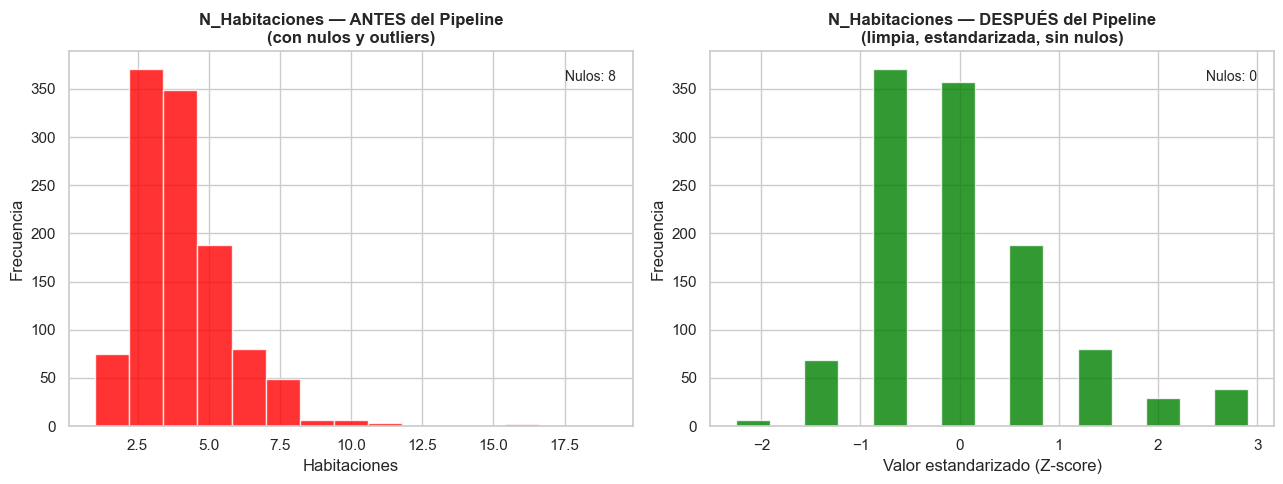

In [15]:
# Comparar distribuciones de N_Habitaciones antes vs después del pipeline
df_raw_plot = pd.read_excel('data/raw/Casas_usadas_-_RM_Mayo_2020.xlsx')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ANTES
axes[0].hist(df_raw_plot['N_Habitaciones'].dropna(), bins=15,
             color='red', edgecolor='white', alpha=0.8)
axes[0].set_title('N_Habitaciones — ANTES del Pipeline\n(con nulos y outliers)', fontweight='bold')
axes[0].set_xlabel('Habitaciones')
axes[0].set_ylabel('Frecuencia')
axes[0].text(0.97, 0.95, f"Nulos: {df_raw_plot['N_Habitaciones'].isnull().sum()}",
             transform=axes[0].transAxes, ha='right', va='top', fontsize=10)

# DESPUÉS
axes[1].hist(df_final['N_Habitaciones'], bins=15,
             color='green', edgecolor='white', alpha=0.8)
axes[1].set_title('N_Habitaciones — DESPUÉS del Pipeline\n(limpia, estandarizada, sin nulos)', fontweight='bold')
axes[1].set_xlabel('Valor estandarizado (Z-score)')
axes[1].set_ylabel('Frecuencia')
axes[1].text(0.97, 0.95, "Nulos: 0", transform=axes[1].transAxes, ha='right', va='top', fontsize=10)

plt.tight_layout()
plt.savefig('outputs/05_antes_vs_despues_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Conclusiones del Pipeline

### Resumen de transformaciones aplicadas

| Paso | Transformador | Resultado |
|---|---|---|
| 1 | `DropColumnsTransformer` | 13 → 8 columnas (eliminadas 5 irrelevantes) |
| 2 | `ParkingToNumericTransformer` | 'No' → 0 en N_Estacionamientos |
| 3 | `SurfaceToNumericTransformer` | Superficie_Construida_M2 a float64 |
| 4 | `TargetCreatorTransformer` | Variable objetivo creada, leakage eliminado |
| 5 | `DropHighMissingTransformer` | Sin columnas >80% nulos en este dataset |
| 6 | `OutlierCapper` | Winsorización IQR aplicada |
| 7 | `SmartImputerTransformer` | Todos los nulos imputados |
| 8 | `ColumnTransformer` | StandardScaler + OneHotEncoder |

### El pipeline es:
- **Reproducible**: mismos resultados con cualquier subconjunto del dataset.
- **Sin data leakage**: `Valor_UF` y `Valor_CLP` eliminados antes del modelado.
- **Escalable**: arquitectura compatible con train/test split y GridSearchCV.
